In [1]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt
import time
import numpy as np
from sklearn.manifold import MDS
from sklearn.metrics import silhouette_score


pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

C:\Users\adams\AppData\Local\Temp/ipykernel_32640/296405123.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [2]:
samples_df, cns_df = cdu.main_load("3MB")
cns_df = cns.only_aut(cns.add_total_cn(cns_df))
subs_df = pd.concat([cns.select_cns_by_type(cns_df, samples_df, "LUAD"), cns.select_cns_by_type(cns_df, samples_df, "LUSC")])
# subs_df = cns.cns_head(cns_df, 400)

In [3]:
start = time.time()
dist_matrix = cns.calc_distances(subs_df, "total_cn")
print(f"Elapsed time: {time.time() - start:.2f} seconds")
dist_matrix.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_dist_matrix.tsv"), sep="\t", index=True, header=True)

Elapsed time: 76.19 seconds


In [4]:
# Get sample metadata (assuming samples_df has metadata we can use)
sample_metadata = samples_df.loc[dist_matrix.index]

# Perform MDS on the distance matrix
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
positions = mds.fit_transform(dist_matrix.values)

# Create a DataFrame with MDS results
mds_df = pd.DataFrame(positions, columns=['MDS1', 'MDS2'], index=dist_matrix.index)

# Merge with metadata (adjust this based on your actual metadata structure)
# If you have a 'type' or 'subtype' column that would be useful for coloring
if 'type' in sample_metadata.columns:  # Adjust column name as needed
    mds_df['type'] = sample_metadata['type']

In [99]:
samples_df

,sex,type,histology_tier2,TCGA_id,chrom_count,...,step_total_cn_aut,step_total_cn_sex,step_total_cn_all,source,TRACERx_set
sample_id,,,,,,,,,,,
SP101724,xx,OV,Ovary,0,23,...,1.671488,1.382353,1.652510,PCAWG,NaN
SP98853,xy,LINC,Liver,0,24,...,1.081633,1.000000,1.074074,PCAWG,NaN
SP47708,xx,LGG,CNS,TCGA-EZ-7264,23,...,1.000000,0.000000,1.000000,PCAWG,NaN
SP106808,xx,PAEN,Pancreas,0,23,...,1.000000,1.000000,1.000000,PCAWG,NaN
SP102816,xx,RECA,Kidney,0,23,...,1.000000,0.000000,1.000000,PCAWG,NaN
...,...,...,...,...,...,...,...,...,...,...,...
TCGA-ZS-A9CE,xx,LIHC,NaN,NaN,23,...,1.600000,0.000000,1.600000,TCGA_hg19,NaN
TCGA-ZS-A9CF-a,xy,LIHC,NaN,NaN,23,...,1.250965,1.000000,1.242537,TCGA_hg19,NaN
TCGA-ZS-A9CG,xy,LIHC,NaN,NaN,23,...,3.000000,1.200000,1.800000,TCGA_hg19,NaN


In [100]:
luad_samples = samples_df[samples_df['type'] == 'LUAD'].index
lusc_samples = samples_df[samples_df['type'] == 'LUSC'].index

In [ ]:
print(dist_matrix.loc[luad_samples].iloc[0,:].mean())
print(dist_matrix.loc[lusc_samples].iloc[0,:].mean())

CRUK0001_SU_T1-R1
0.32089600036937227
0.3667633986329868


In [122]:
# Calculate mean distance to LUAD and LUSC samples for each sample in dist_matrix
mean_dist_to_luad = dist_matrix.loc[luad_samples].mean(axis=0)
mean_dist_to_lusc = dist_matrix.loc[lusc_samples].mean(axis=0)

mean_dist_df = pd.DataFrame({
    'dist_luad': mean_dist_to_luad,
    'dist_lusc': mean_dist_to_lusc
})

mean_dist_df["type"] = samples_df["type"]

mean_dist_df["diff"] = np.where(mean_dist_df["type"] == "LUAD", mean_dist_df["dist_lusc"] - mean_dist_df["dist_luad"], mean_dist_df["dist_luad"] - mean_dist_df["dist_lusc"])

mean_dist_df

,dist_luad,dist_lusc,type,diff
sample_id,,,,
CRUK0001_SU_T1-R1,0.308458,0.348508,LUAD,0.040050
CRUK0001_SU_T1-R2,0.327619,0.362137,LUAD,0.034518
CRUK0001_SU_T1-R3,0.317255,0.343224,LUAD,0.025968
CRUK0002_SU_T1-R1,0.358984,0.388015,LUAD,0.029030
CRUK0002_SU_T1-R2,0.370248,0.395460,LUAD,0.025212
...,...,...,...,...
TCGA-O2-A52W,0.401640,0.354936,LUSC,0.046703
TCGA-O2-A5IB,0.383748,0.383510,LUSC,0.000238
TCGA-O2-A5IC,0.294266,0.315013,LUSC,-0.020747


In [123]:
# Only calculate silhouette score if there are at least 2 clusters
labels = mds_df['type'].values
sil_score = silhouette_score(mds_df[['MDS1', 'MDS2']].values, labels)
print(f"Silhouette score (using sample type as clusters): {sil_score:.3f}")

Silhouette score (using sample type as clusters): 0.311


In [124]:
std = mean_dist_df["diff"].std()
outliers_df = mean_dist_df[mean_dist_df["diff"] < 0]
outliers_df.shape

(240, 4)

2307 -44.351181436192235 70 70


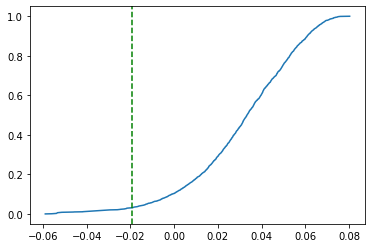

In [125]:
x, y, knee_pos, knee_val, elbow_pos, elbow_val = cns.find_bends(mean_dist_df.sort_values("diff")["diff"])
print(knee_pos, knee_val, elbow_pos, elbow_pos)
plt.plot(x, y)
plt.axvline(x=x[elbow_pos], color='g', linestyle='--')


In [126]:
std = mean_dist_df["diff"].std()
outliers_df = mean_dist_df[mean_dist_df["diff"] < x[elbow_pos]]
outliers_df.shape

(72, 4)

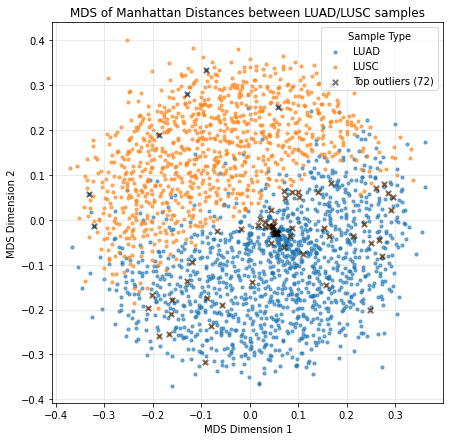

In [128]:
# Plot MDS results
plt.figure(figsize=(7, 7))

# If type information is available, use it for coloring
types = mds_df['type'].unique()
for i, t in enumerate(types):
	mask = mds_df['type'] == t
	plt.scatter(mds_df.loc[mask, 'MDS1'], mds_df.loc[mask, 'MDS2'], 
				label=t, color=color_map[i % len(color_map)], s=10, alpha=0.6)

plt.scatter(mds_df.loc[outliers_df.index, 'MDS1'],
			mds_df.loc[outliers_df.index, 'MDS2'],
			marker='x', color='black', s=30, alpha=.5, linewidths=2, label=f'Top outliers ({len(outliers_df)})')

plt.legend(title='Sample Type')
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS of Manhattan Distances between LUAD/LUSC samples')
plt.grid(alpha=0.3)

# Optionally save the MDS results
mds_df.to_csv(cdu.pjoin(cdu.out_path, "LUAD_LUSC_mds_positions.tsv"), sep="\t", index=True)
cdu.save_cns_fig("LUAD_LUSC_mds_positions")

In [130]:
lusc_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUSC'"))
luad_df = cns.select_CNS_samples(cns_df, samples_df.query("type == 'LUAD'"))
lusc_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUSC'"))
luad_outliers_df = cns.select_CNS_samples(cns_df, outliers_df.query("type == 'LUAD'"))

lusc_group = cns.group_samples(lusc_df, group_name="LUSC all")
luad_group = cns.group_samples(luad_df,group_name="LUAD all")
lusc_outliers_group = cns.group_samples(lusc_outliers_df, group_name="LUSC outliers")
luad_outliers_group = cns.group_samples(luad_outliers_df, group_name="LUAD outliers")

all_groups = pd.concat([lusc_group, luad_group, lusc_outliers_group, luad_outliers_group])


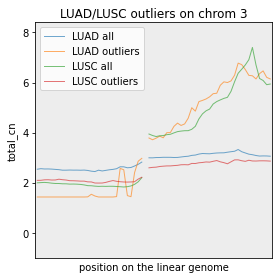

In [131]:
fig, axs = cns.fig_lines(all_groups.query("chrom == 'chr3'"), cn_columns="total_cn", colors=color_map[:4])
fig.set_size_inches(4, 4)
axs.legend()
plt.title("LUAD/LUSC outliers on chrom 3")
axs.set_xticks([cns.hg19.chr_starts["chr3"], cns.hg19.chr_starts["chr4"]])
axs.set_xticklabels([cns.hg19.chr_starts["chr3"], cns.hg19.chr_starts["chr4"]])
# nullify small ticks
axs.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

cdu.save_cns_fig("LUAD_LUSC_outliers")

In [154]:
outlier_counts = outliers_df.merge(samples_df[["source"]], left_on="sample_id", right_index=True)["source"].value_counts().sort_index()
val_counts = samples_df.query("type == 'LUAD' or type == 'LUSC'")[["source"]].value_counts().sort_index()
print(outlier_counts)
print(val_counts)
# calculate the percentage of outliers in each source
fractions  = outlier_counts.values / val_counts.values
fractions_df = pd.DataFrame(fractions, index=outlier_counts.index, columns=["fraction"])
fractions_df = fractions_df.reset_index()
print(fractions_df)

source
PCAWG         2
TCGA_hg19    50
TRACERx      20
Name: count, dtype: int64
source   
PCAWG          82
TCGA_hg19     906
TRACERx      1322
Name: count, dtype: int64
      source  fraction
0      PCAWG  0.024390
1  TCGA_hg19  0.055188
2    TRACERx  0.015129
